In [181]:
### TODO:
# fix hard-coded geometry fill functions
# add title -- e.g. f'$\mu^+$ and $\mu^-$ trajectories (exaggerated by factor of {scale})'
# make hatched pattern on solenoids only for region between inner and outer radius
# add timing offsets (and play with other sigmas) to particle tracks w/ beam

In [128]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
from matplotlib.colors import ListedColormap

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from functions.read_g4bl_data import readTraceData
from functions.set_plot_settings import setPlotSettings

setPlotSettings(font=True)

## w/ mu+ and mu- reference tracks

In [ ]:
# Location of G4bl output:
dir = 'g4bl-output/'

# Define RF period:
f = 325*10**6 # MHz
T = 1/f*10**9 # ns

# Length of period:
len_period = 4200 # mm

# First solenoid z placement:
zstart = 500 # mm

# Figure directory:
fig_dir = 'figures/'

In [ ]:
# Read in data:
data = readTraceData(dir+'AllTracks.txt')
z_vals = data['z'].values # mm

# Find indices for first value in each period:
next_z = 0
period_start_z_vals = []
period_start_indices = []
for i in range(len(z_vals)):
    if z_vals[i] > next_z:
        period_start_z_vals.append(z_vals[i])
        period_start_indices.append(i)
        next_z += len_period

# Remove last two periods (for reducing edge fields):
if len(period_start_indices) > 1:
    final_index = period_start_indices[-2]
else:
    final_index = len(z_vals)
data = data.iloc[:final_index-1].copy()
x_vals = data['x'].values; y_vals = data['y'].values; z_vals = data['z'].values # mm
px_vals = data['px'].values; py_vals = data['py'].values; pz_vals = data['pz'].values; ptotal_vals = data['ptotal'].values # MeV/c
t_vals = data['t'].values # ns
Bx_vals = data['Bx'].values; By_vals = data['By'].values; Bz_vals = data['Bz'].values # T
xp_vals = data['xp'].values; yp_vals = data['yp'].values # radians
r_vals = data['r'].values # mm
theta_vals = data['theta'].values # radians
rp_vals = data['rp'].values # radians
thetap_vals = data['thetap'].values # radians
Lz_vals = data['Lz'].values # mm*MeV/c

In [131]:
data = data[period_start_indices[0]:period_start_indices[1]]

In [132]:
# Number of solenoids:
n = 6

# Distance between solenoids:
d = 700 # mm

# Solenoid length:
L = 300 # mm

# Solenoid outer diameter:
h = 600*2 # mm

# Solenoid inner diameter:
hinner = 420*2 # mm

# RF cavity length (of two adjacent pillboxes):
LRF = 500 # mm

# RF cavity height (approx. outer diameter):
hRF = 300*2 # mm

# height of absorber:
habs = 350 # mm

# length of absorber (approx. avg. lower radius):
Labs = 45 # mm

### Define function to shade regions indicating solenoid geometry:
def plot_solenoids(ax, zshift=0, legend=True):
    cnt1 = 0; cnt2 = 0
    for i in range(n):
        center = 500 + i*d + zshift
        if np.mod(i,2) == 0: # positive polarity
            if cnt1 == 0 and legend:
                ax.axvspan(xmin=center-L/2, xmax=center+L/2, color='gray', ymin=0, ymax=1, alpha=0.8, label='$+$ solenoid', hatch='X')
                cnt1 += 1
            else:
                ax.axvspan(xmin=center-L/2, xmax=center+L/2, color='gray', ymin=0, ymax=1, alpha=0.8, hatch='X')
        else: # negative polarity
            if cnt2 == 0 and legend:
                ax.axvspan(xmin=center-L/2, xmax=center+L/2, color='black', ymin=0, ymax=1, alpha=0.8, label='$-$ solenoid', hatch='X')
                cnt2 += 1
            else:
                ax.axvspan(xmin=center-L/2, xmax=center+L/2, color='black', ymin=0, ymax=1, alpha=0.8, hatch='X')

### Define function to shade regions indicating RF geometry:
def plot_RF(ax, zshift=0, legend=True):
    cnt1 = 0
    for i in range(n):
        center = 500 + i*d + zshift
        if cnt1 == 0 and legend:
            ax.axvspan(xmin=center-LRF/2, xmax=center+LRF/2, color='darkred', ymin=0.25, ymax=0.75, alpha=0.9, label='RF cavity')
            cnt1 += 1
        else:
            ax.axvspan(xmin=center-LRF/2, xmax=center+LRF/2, color='darkred', ymin=0.25, ymax=0.75, alpha=0.9)

### Define function to shade regions indicating absorber placement:
def plot_abs(ax, zshift=0, legend=True):
    cnt1 = 0
    for i in range(n):
        center_gap = 500 + i*d + zshift + 350
        if cnt1 == 0 and legend:
            ax.axvspan(xmin=center_gap-Labs/2, xmax=center_gap+Labs/2, color='teal', ymin=0.25+0.125, ymax=0.75-0.125, alpha=0.9, label='LiH absorber')
            cnt1 += 1
        else:
            ax.axvspan(xmin=center_gap-Labs/2, xmax=center_gap+Labs/2, color='teal', ymin=0.25+0.125, ymax=0.75-0.125, alpha=0.9)

In [133]:
# Set start and end indices for single period to consider:
start = period_start_indices[1]-1
end = period_start_indices[2]

In [134]:
# Scale factor to apply to tracks (in y direction):
scale = 3

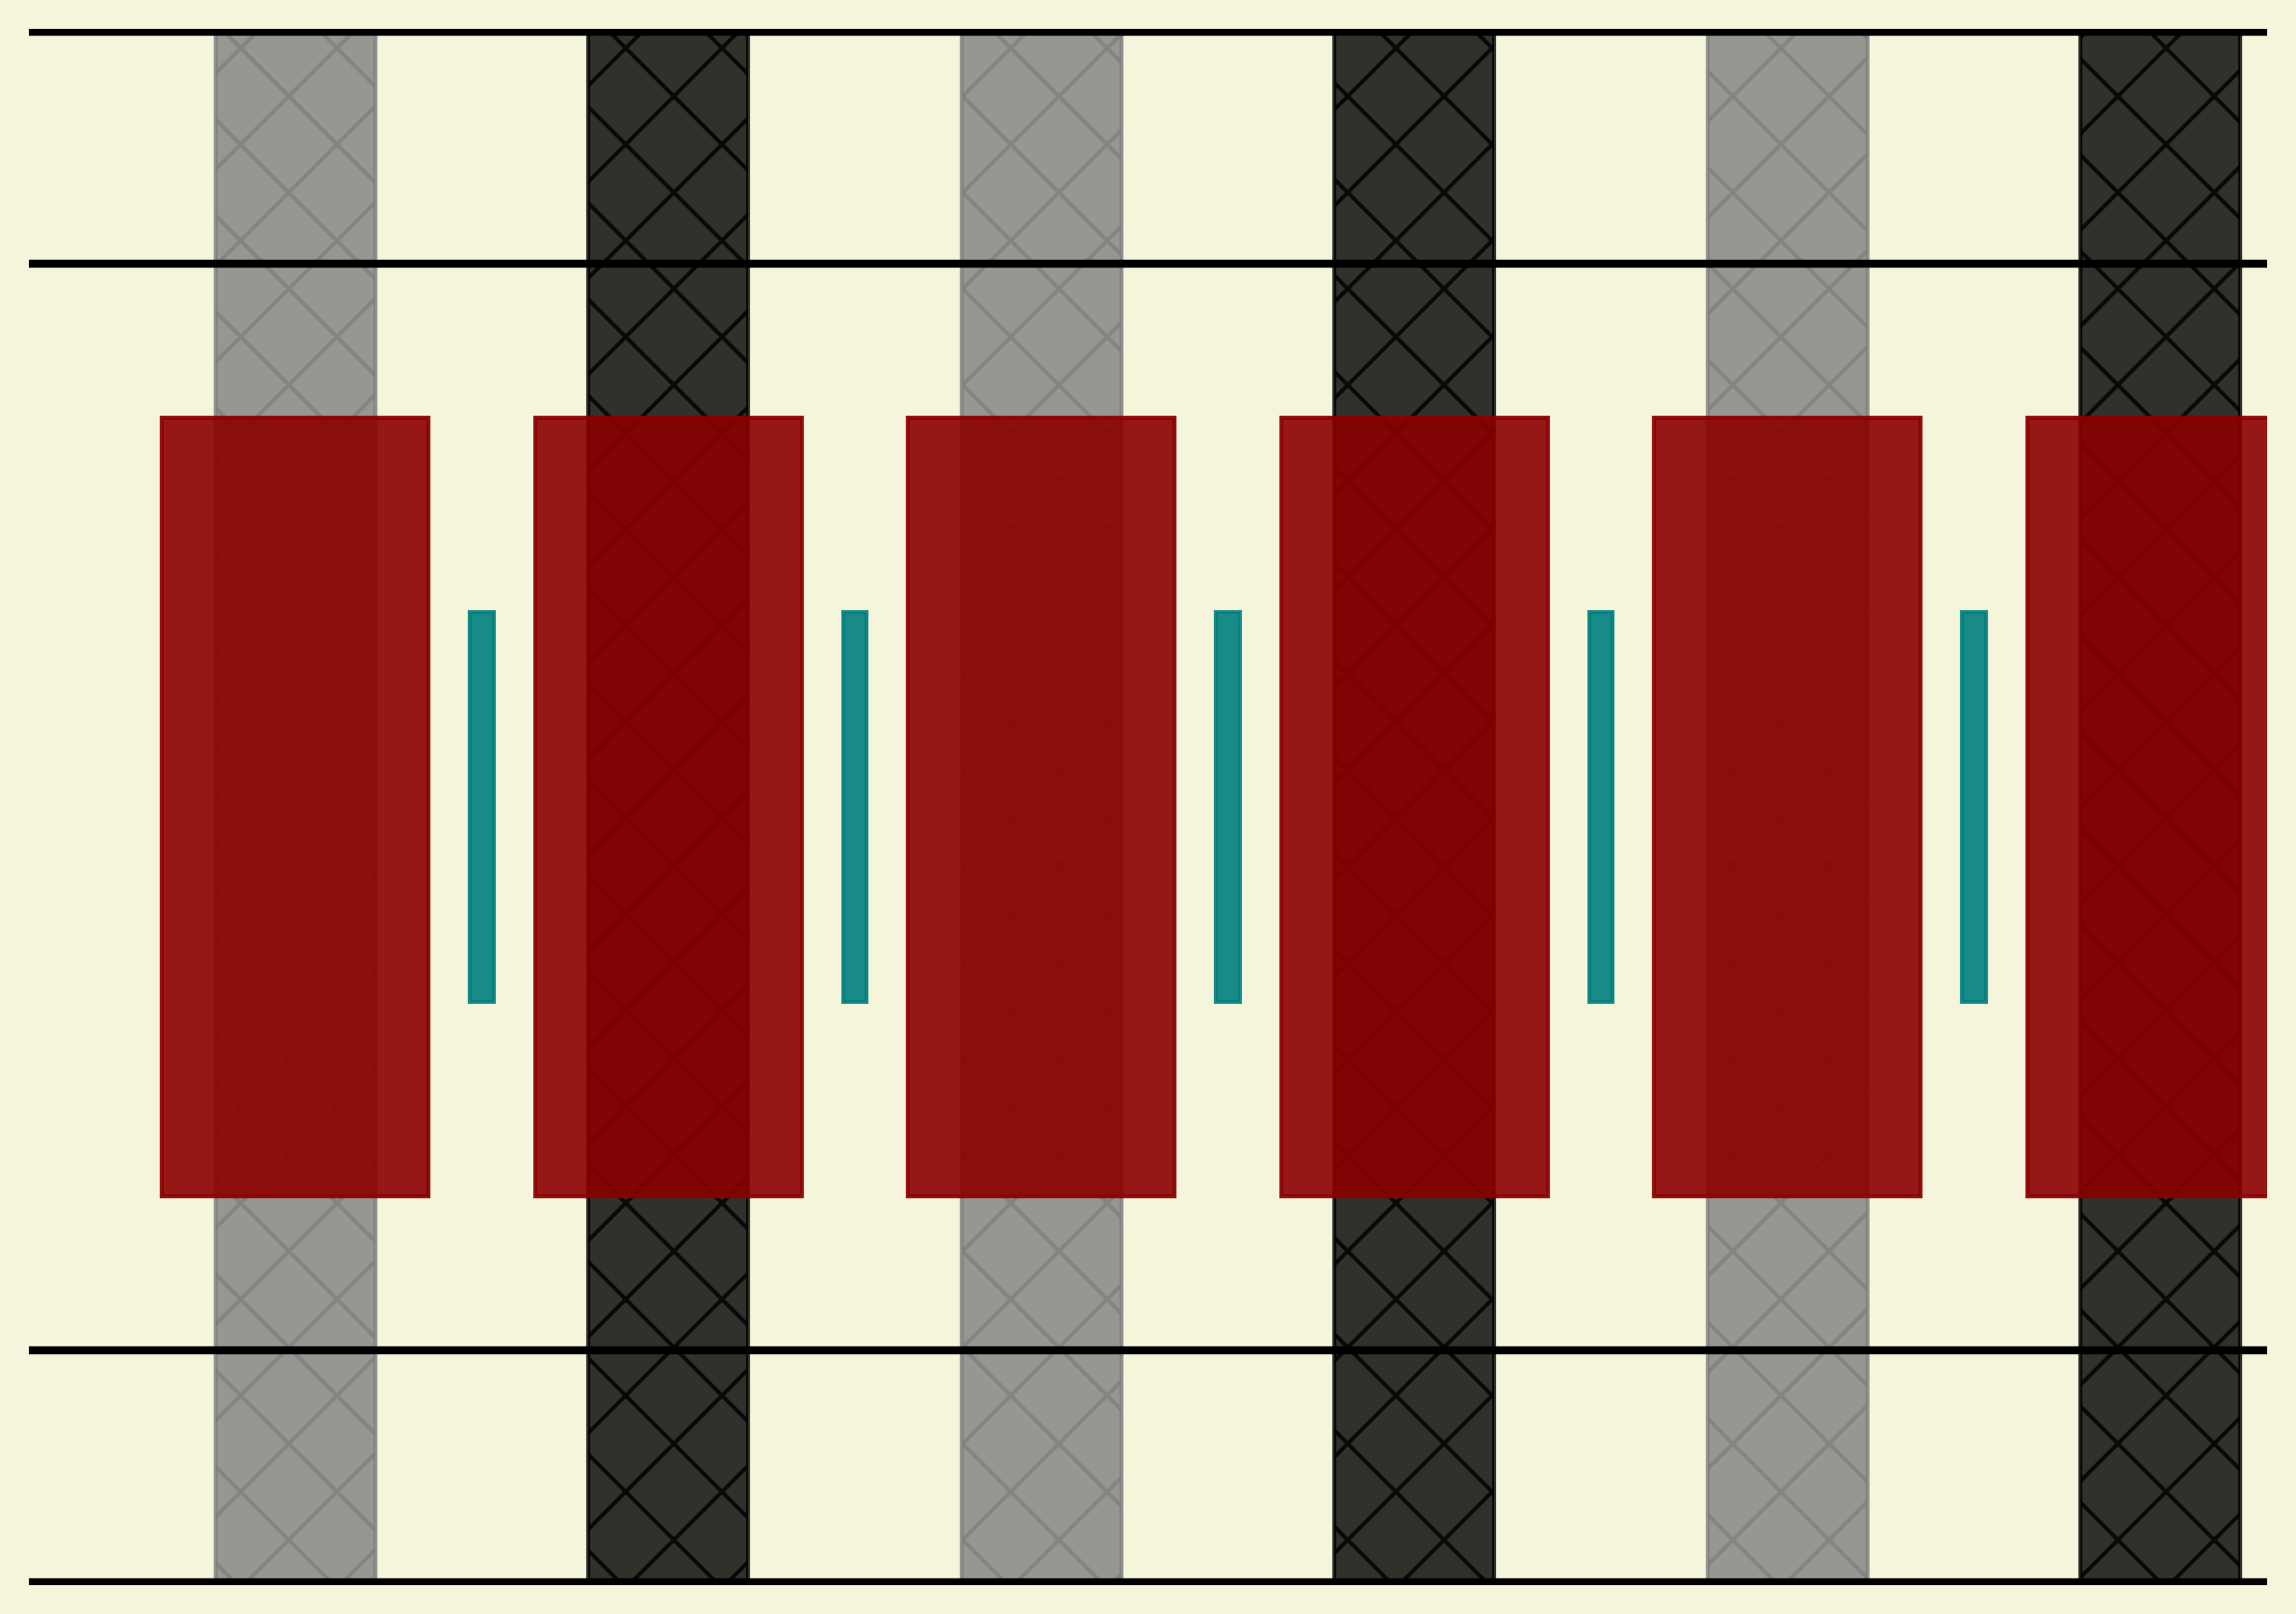

In [135]:
# Generate mu- orbit:
start = int( (period_start_indices[1] - period_start_indices[0]) /2 )
end = period_start_indices[1] + start
minus_x = x_vals[start:end]
minus_y = y_vals[start:end]

# Animation of trajectory in yz- and xy-planes for both signs:
fig, ax1 = plt.subplots(1,1, figsize=(10, 7))
fig.set_facecolor('beige')
ax1.set_facecolor('beige')
sol_placements = np.arange(z_vals[period_start_indices[0]],z_vals[period_start_indices[1]+2],0.7)
def animate(frame):

    ax1.cla()

    plot_solenoids(ax1)
    plot_RF(ax1)
    plot_abs(ax1)
    ax1.axhline(420, color='black', lw=2)
    ax1.axhline(-420, color='black', lw=2)
    ax1.axhline(600, color='black', lw=2)
    ax1.axhline(-600, color='black', lw=2)

    # for i in range(n):
    #     center = 500 + i*d - 35
    #     if np.mod(i,2) == 0: # positive polarity
    #         ax1.text(center, 425, s='$+$')
    #     else: # negative polarity
    #         ax1.text(center, 425, s='$-$')

    # y,z plot:
    # ax1.plot(z_vals[:frame],y_vals[:frame],color='blue',linewidth=1) # mu+
    # ax1.plot(z_vals[:frame],minus_y[:frame],color='red',linewidth=1) # mu-
    ax1.plot(z_vals[:frame],y_vals[:frame]*scale,color='white',linewidth=3) # mu+
    ax1.scatter(z_vals[frame-1],y_vals[frame-1]*scale,color='white')
    ax1.plot(z_vals[:frame],minus_y[:frame]*scale,color='white',linewidth=3) # mu-
    ax1.scatter(z_vals[frame-1],minus_y[frame-1]*scale,color='white')
    ax1.set_xlim((0,4200))
    ax1.set_ylim((-602, 602))
    ax1.set_ylabel('y [mm]')
    ax1.set_xlabel('z [mm]')
    ax1.axis('off')
    # ax1.legend(loc='upper left')

plot_solenoids(ax1)
animation = FuncAnimation(fig, animate, frames=len(z_vals[period_start_indices[0]:period_start_indices[1]+2]), interval=200, repeat=True)
animation.save(fig_dir+'HFOFO_animation_v1.gif', writer='pillow')

## w/ 10 tracks (offset position and momentum w.r.t. reference)

In [ ]:
data_beam = readTraceData(dir+'AllTracks_foranimation.txt')

In [ ]:
np.unique(data_beam['EventID'])

array([-2., -1.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [ ]:
data1 = data_beam[data_beam['EventID']==1]
data2 = data_beam[data_beam['EventID']==2]
data3 = data_beam[data_beam['EventID']==3]
data4 = data_beam[data_beam['EventID']==4]
data5 = data_beam[data_beam['EventID']==5]
data6 = data_beam[data_beam['EventID']==6]
data7 = data_beam[data_beam['EventID']==7]
data8 = data_beam[data_beam['EventID']==8]
data9 = data_beam[data_beam['EventID']==9]
data10 = data_beam[data_beam['EventID']==10]

In [177]:
def func(data):
    if len(period_start_indices) > 1:
        final_index = period_start_indices[-2]
    else:
        final_index = len(z_vals)
    data = data.iloc[:final_index-1].copy()
    return data

In [178]:
data1 = func(data1)
data2 = func(data2)
data3 = func(data3)
data4 = func(data4)
data5 = func(data5)
data6 = func(data6)
data7 = func(data7)
data8 = func(data8)
data9 = func(data9)
data10 = func(data10)

In [179]:
scale2 = 1

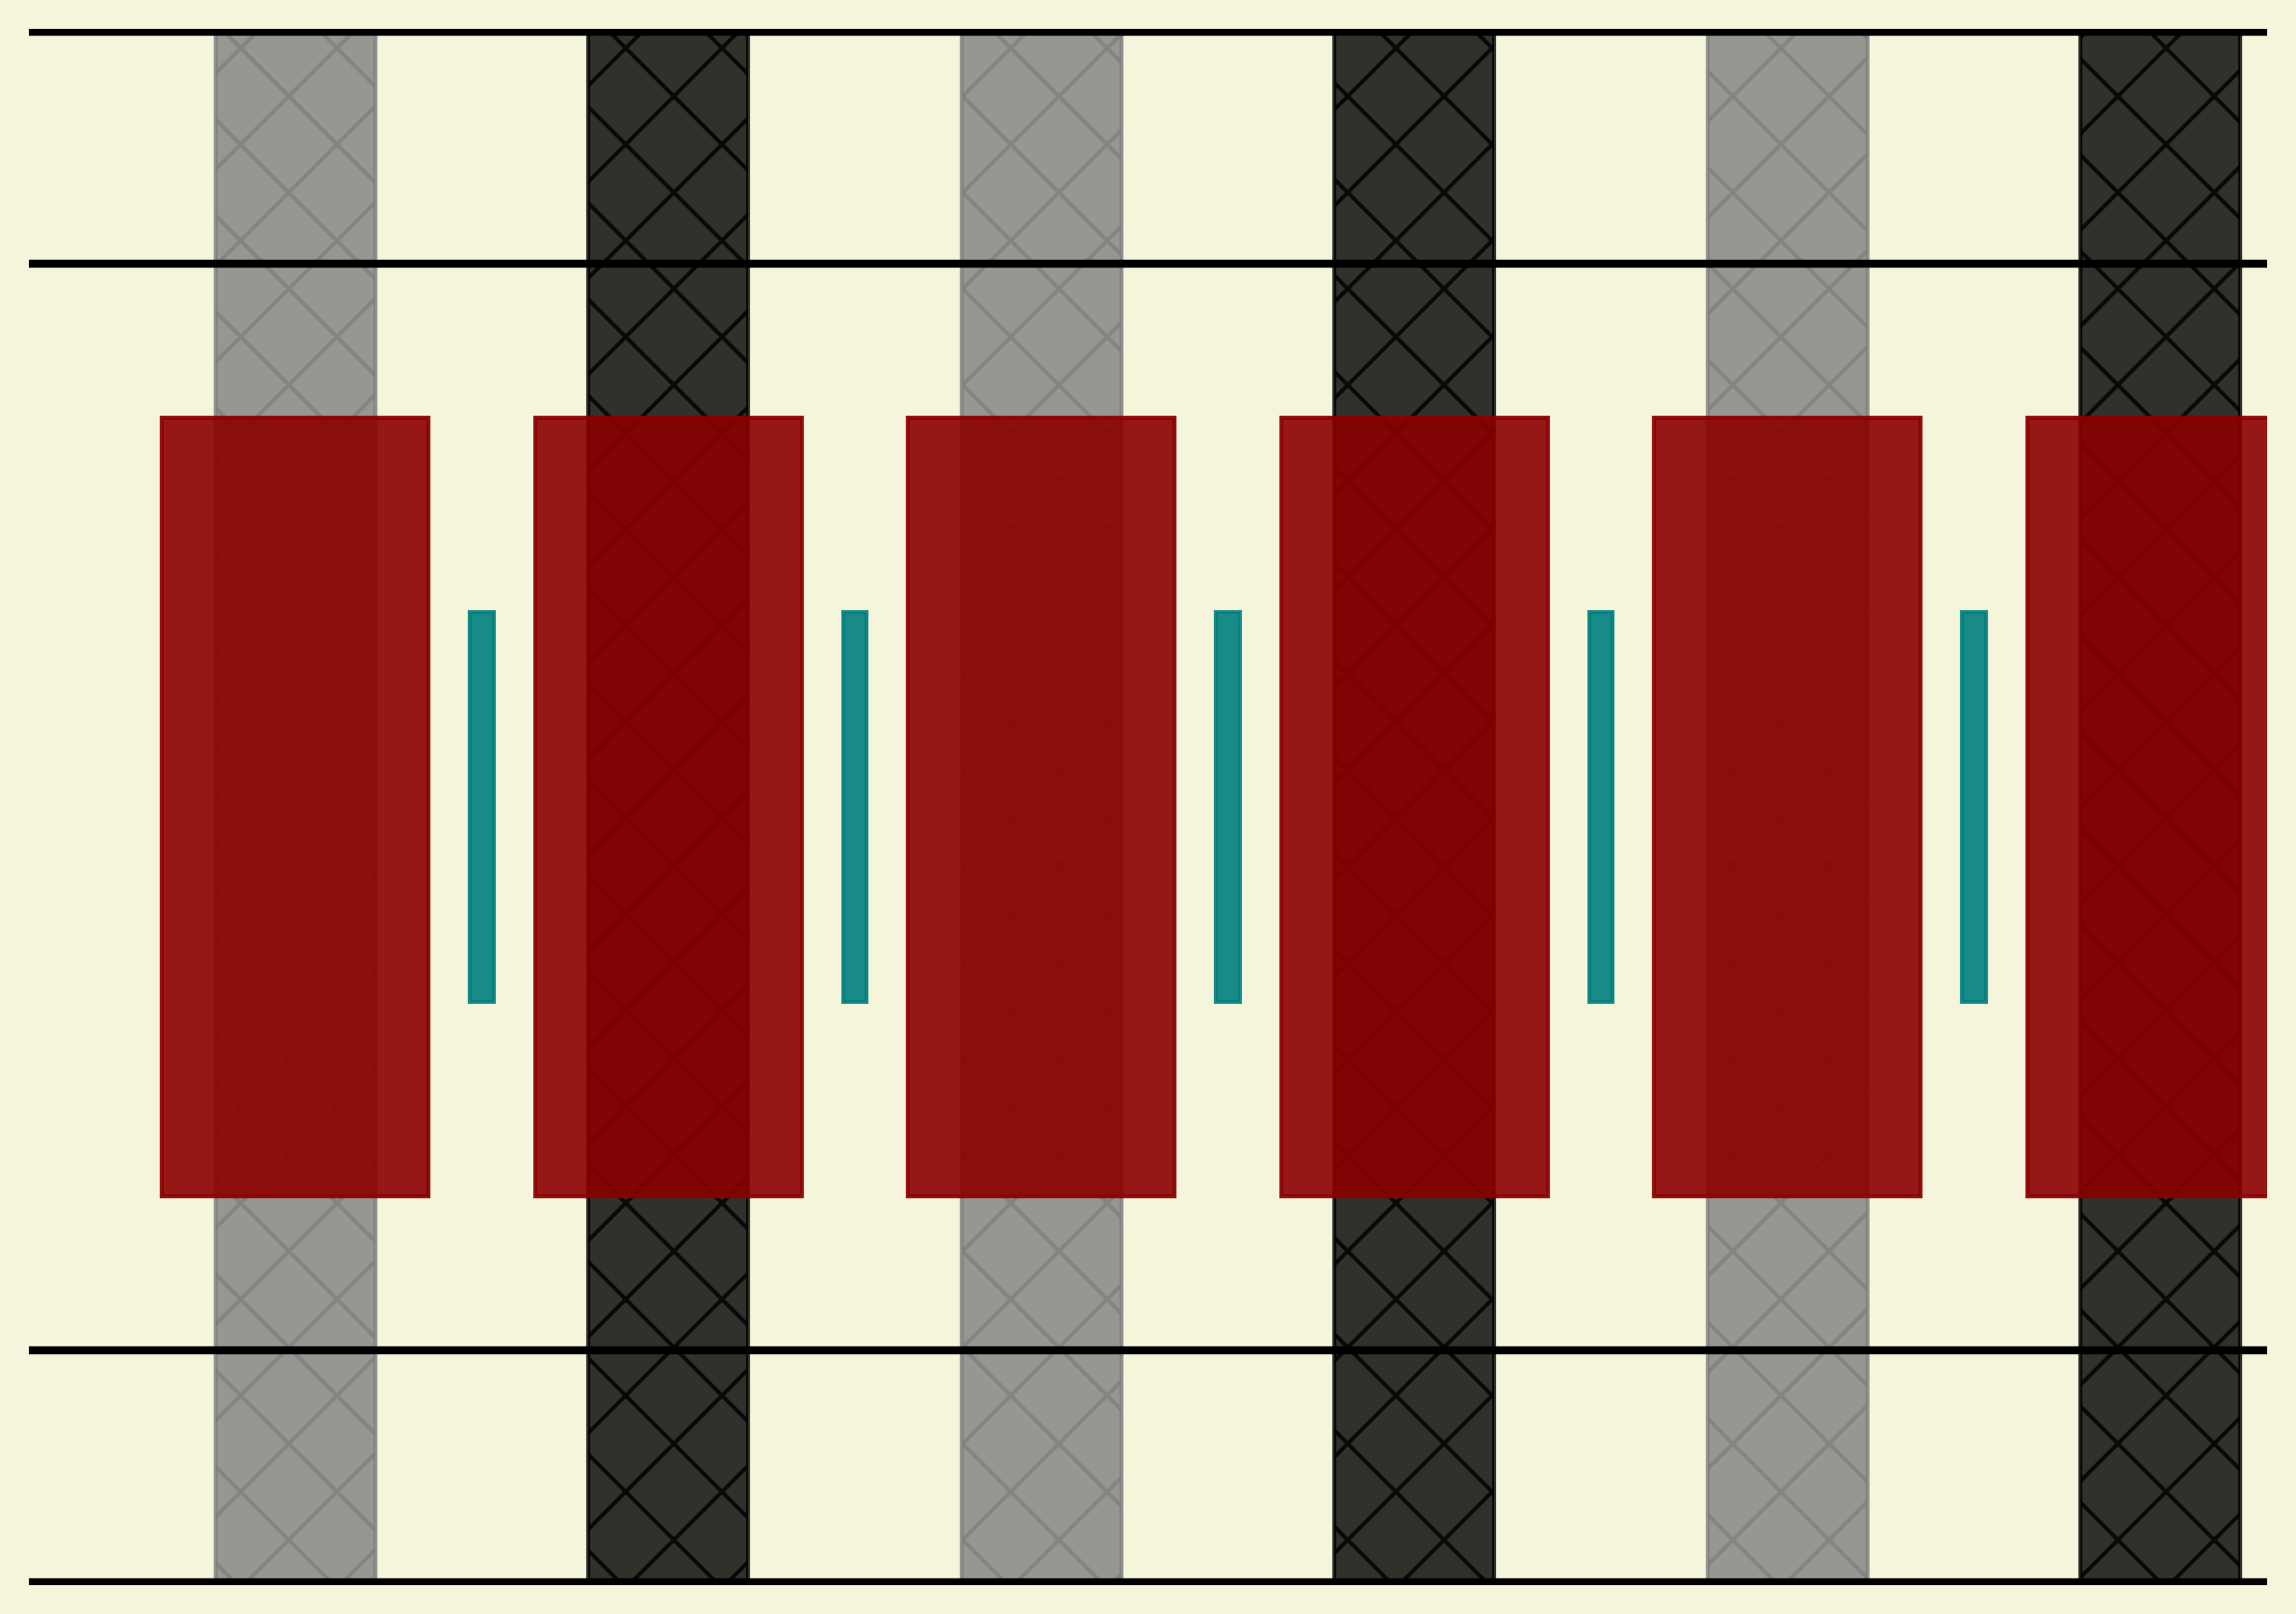

In [180]:
# Animation of trajectory in yz- and xy-planes for both signs:
fig, ax1 = plt.subplots(1,1, figsize=(10, 7))
fig.set_facecolor('beige')
ax1.set_facecolor('beige')
sol_placements = np.arange(data1['z'].values[period_start_indices[0]],data1['z'].values[period_start_indices[1]+2],0.7)
def animate(frame):

    ax1.cla()

    plot_solenoids(ax1)
    plot_RF(ax1)
    plot_abs(ax1)
    ax1.axhline(420, color='black', lw=2)
    ax1.axhline(-420, color='black', lw=2)
    ax1.axhline(600, color='black', lw=2)
    ax1.axhline(-600, color='black', lw=2)

    # y,z plot:
    ax1.plot(data1['z'].values[:frame],data1['y'].values[:frame]*scale2,color='white',linewidth=3) # track 1
    ax1.scatter(data1['z'].values[frame-1],data1['y'].values[frame-1]*scale2,color='white')
    ax1.plot(data2['z'].values[:frame],data2['y'].values[:frame]*scale2,color='white',linewidth=3) # track 2
    ax1.scatter(data2['z'].values[frame-1],data2['y'].values[frame-1]*scale2,color='white')
    ax1.plot(data3['z'].values[:frame],data3['y'].values[:frame]*scale2,color='white',linewidth=3) # track 3
    ax1.scatter(data3['z'].values[frame-1],data3['y'].values[frame-1]*scale2,color='white')
    ax1.set_xlim((0,4200))
    ax1.set_ylim((-602, 602))
    ax1.axis('off')

plot_solenoids(ax1)
animation = FuncAnimation(fig, animate, frames=len(data1['z'].values[period_start_indices[0]:period_start_indices[1]+2]), interval=200, repeat=True)
animation.save(fig_dir+'HFOFO_animation_v2.gif', writer='pillow')